## Busca Ordenada

Busca de custo uniforme seguindo o Algoritmo Básico de Busca, com `abertos` como **fila ordenada pelo menor custo acumulado** (g = soma dos custos das regras da raiz até o nó) e `fechados` para os nós já expandidos.
O teste de objetivo é feito quando o nó **vira estado atual** (sai de `abertos`), nunca ao ser gerado; por isso a solução encontrada é a de **menor custo**, e não necessariamente a de menor número de movimentos.

Regras de ordenação de `abertos`:
- sempre ordenada pelo custo g; em empate, o nó gerado primeiro fica na frente;
- `ORDER` só decide a ordem entre filhos do **mesmo pai** com o **mesmo custo**;
- **poda** (`PRUNING = True`): vetor de menor custo — estado repetido com custo maior ou igual é descartado; com custo menor, substitui o nó antigo em `abertos`.

### Funções de custo real

BFS e DFS tratam toda regra com custo 1. Para a Busca Ordenada precisamos de um custo numérico por regra `r → (origem, destino)`. Definimos duas funções em `algorithms/utils.py`, ambas com assinatura `cost(rule, state)` (o estado é necessário porque uma delas depende da cor da peça movida):

**1. `direcao` — custo pela direção do movimento**

As brancas (`bx`, `by`) começam nas casas 1 e 3 (linha de cima do tabuleiro) e precisam chegar às casas 7 e 9 (linha de baixo); as pretas (`px`, `py`) fazem o oposto. Como o custo é medido em **linhas** (todo salto de cavalo muda a peça de linha), chamamos de linha-objetivo a linha de baixo (casas 7-8-9) para as brancas e a linha de cima (casas 1-2-3) para as pretas, e comparamos a distância da peça até essa linha antes e depois do salto:

| Efeito do salto na peça movida | Custo |
|---|---|
| aproxima da linha-objetivo | **1** |
| afasta da linha-objetivo | **3** |

Num tabuleiro 3x3 todo salto de cavalo muda de linha, logo não existe movimento "lateral": a função só devolve 1 ou 3. A ideia é penalizar movimentos que andam "para trás", algo que BFS/DFS não distinguem.

**2. `destino` — custo pela casa de destino**

Independe da peça; olha só para onde o cavalo pousa:

| Casa de destino | Custo |
|---|---|
| canto (1, 3, 7, 9) | **1** |
| borda (2, 4, 6, 8) | **2** |

Os cantos são as casas-objetivo de todas as peças e também as casas de onde um cavalo tem menos saídas; pousar numa borda é um movimento "intermediário", por isso custa mais. (A casa central 5 nunca é alcançada por um cavalo no 3x3.)

Tabela regra → custo de `destino` (fixa, pois não depende da peça):

| Regra | r1 | r2 | r3 | r4 | r5 | r6 | r7 | r8 | r9 | r10 | r11 | r12 | r13 | r14 | r15 | r16 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| origem → destino | 1→6 | 1→8 | 2→7 | 2→9 | 3→4 | 3→8 | 4→3 | 4→9 | 6→1 | 6→7 | 7→2 | 7→6 | 8→1 | 8→3 | 9→2 | 9→4 |
| custo | 2 | 2 | 1 | 1 | 2 | 2 | 1 | 1 | 1 | 1 | 2 | 2 | 1 | 1 | 2 | 2 |

Para `direcao` o custo da mesma regra varia com a peça: por exemplo `r1 (1→6)` custa 1 se quem está na casa 1 é uma branca (desce) e 3 se é uma preta (sobe de volta).

**Parâmetros:**
- `COST` — função de custo: `"direcao"` ou `"destino"`
- `ORDER` — desempate entre filhos do mesmo pai com o mesmo custo: `"asc"` (r1→r16) ou `"desc"` (r16→r1)
- `PRUNING` — `True`: poda pelo vetor de menor custo; `False`: permite repetidos (árvore ingênua, use `MAX_DEPTH`)
- `MAX_DEPTH` — profundidade máxima de expansão quando `PRUNING = False` (ignorado se `PRUNING = True`)

Código: `algorithms/ordered.py` (algoritmo) e `algorithms/utils.py` (funções de custo)


In [1]:
import sys
from pathlib import Path
import importlib

sys.path.insert(0, str(Path("algorithms").resolve()))

import ordered
import utils
from utils import INITIAL_STATE

importlib.reload(utils)
importlib.reload(ordered)

COST      = "direcao"  # "direcao" → 1 aproxima / 3 afasta  |  "destino" → 1 canto / 2 borda
ORDER     = "asc"      # "asc"  → r1, r2, …, r16  |  "desc" → r16, r15, …, r1  (só desempata filhos do mesmo pai)
PRUNING   = True       # True  = poda pelo vetor de menor custo (encontra a solução de menor custo)
                       # False = permite repetidos — use MAX_DEPTH para limitar a busca
MAX_DEPTH = 3          # profundidade máxima quando PRUNING = False (ignorado se PRUNING = True)

depth_arg = None if PRUNING else MAX_DEPTH

result = ordered.ordered(INITIAL_STATE, cost=COST, order=ORDER, pruning=PRUNING, max_depth=depth_arg)

# Desempacota resultado
if result is None:
    # Fracasso real (PRUNING=True e sem solução)
    print(f"Fracasso: abertos esvaziou sem encontrar solução "
          f"(cost={COST!r}, order={ORDER!r}, pruning={PRUNING}).")
    path = applied = node_tree = trace = goal_id = None
else:
    path, applied, stats, node_tree, trace, goal_id = result
    pruning_str = "com poda" if PRUNING else f"sem poda (max_depth={depth_arg})"
    if path is not None:
        # Solução encontrada
        print(f"Sucesso! Solução com {len(applied)} movimentos e custo {stats['cost']} "
              f"({stats['expanded']} nós expandidos, "
              f"máx. de abertos = {stats['max_open']}, "
              f"cost={COST!r}, order={ORDER!r}, {pruning_str}):")
        print(" -> ".join(applied))
    else:
        # Sem poda + max_depth: árvore explorada, sem solução dentro do limite
        print(f"Árvore explorada sem poda até profundidade {depth_arg}: "
              f"{stats['expanded']} nós expandidos, "
              f"{len(node_tree)} nós na árvore "
              f"(nenhuma solução neste limite).")


Sucesso! Solução com 16 movimentos e custo 24 (263 nós expandidos, máx. de abertos = 34, cost='direcao', order='asc', com poda):
r1 -> r6 -> r11 -> r10 -> r16 -> r7 -> r4 -> r16 -> r11 -> r4 -> r13 -> r1 -> r10 -> r6 -> r7 -> r13


In [2]:
# Caminho solução: nível e custo acumulado de cada passo + estado de Abertos e Fechados
# (executado apenas quando uma solução foi encontrada)
if path is not None and goal_id is not None:
    ordered.print_solution(path, applied, node_tree, trace, goal_id, cost=COST, order=ORDER)
else:
    print("Nenhuma solução encontrada — verifique PRUNING e MAX_DEPTH.")



Estado inicial [Nível 0, g=0]:
bx -- by
-- -- --
px -- py

────────────────────────────────────────────────────────────
Passo 1  [Nível 1, g=1]  r1  (1 → 6, custo 1)
  possibilidades (custo): r1(1), r2(1), r5(1), r6(1), r11(1), r12(1), r15(1), r16(1)

  Abertos  (ao expandir nó pai): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz] (g=0)
  Fechados (ao expandir nó pai): (vazio)

  → aplica r1
-- -- by
-- -- bx
px -- py

────────────────────────────────────────────────────────────
Passo 2  [Nível 2, g=2]  r6  (3 → 8, custo 1)
  possibilidades (custo): r5(1), r6(1), r9(3), r11(1), r15(1), r16(1)

  Abertos  (ao expandir nó pai): 8 nós [nível 1: 8 nós]
    • nível 1: [r1] (g=1)
    • nível 1: [r2] (g=1)
    • nível 1: [r5] (g=1)
    • nível 1: [r6] (g=1)
    • nível 1: [r11] (g=1)
    • nível 1: [r12] (g=1)
    • nível 1: [r15] (g=1)
    • nível 1: [r16] (g=1)
  Fechados (ao expandir nó pai): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz] (g=0)

  → aplica r6
-- -- --
-- -- bx
px by py

──────────

In [3]:
# Rastreio completo da Busca Ordenada (★ = nó no caminho solução)
# Ajuste MAX_ITER para limitar a saída (None = todas as iterações)
MAX_ITER = 20   # None para ver tudo
if node_tree is not None:
    ordered.print_trace(trace, node_tree, goal_id, max_iterations=MAX_ITER)
else:
    print("Sem resultados para exibir.")



══════════════════════════════════════════════════════════════════════
RASTREIO BUSCA ORDENADA — 263 iterações no total
(exibindo apenas as primeiras 20)
══════════════════════════════════════════════════════════════════════

Iteração 1 ★  |  N = nível 0  [raiz] (g=0)
    Abertos (antes): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz] (g=0)
    Fechados (antes): (vazio)
  Gerou 8 filho(s): [r1] (g=1) (via r1), [r2] (g=1) (via r2), [r5] (g=1) (via r5), [r6] (g=1) (via r6), [r11] (g=1) (via r11), [r12] (g=1) (via r12), [r15] (g=1) (via r15), [r16] (g=1) (via r16)
    Abertos (depois): 8 nós [nível 1: 8 nós]
    • nível 1: [r1] (g=1)
    • nível 1: [r2] (g=1)
    • nível 1: [r5] (g=1)
    • nível 1: [r6] (g=1)
    • nível 1: [r11] (g=1)
    • nível 1: [r12] (g=1)
    … (+2 não exibidos)
    Fechados (depois): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz] (g=0)

Iteração 2 ★  |  N = nível 1  [r1] (g=1)
    Abertos (antes): 8 nós [nível 1: 8 nós]
    • nível 1: [r1] (g=1)
    • nível 1: [r2] (g=1

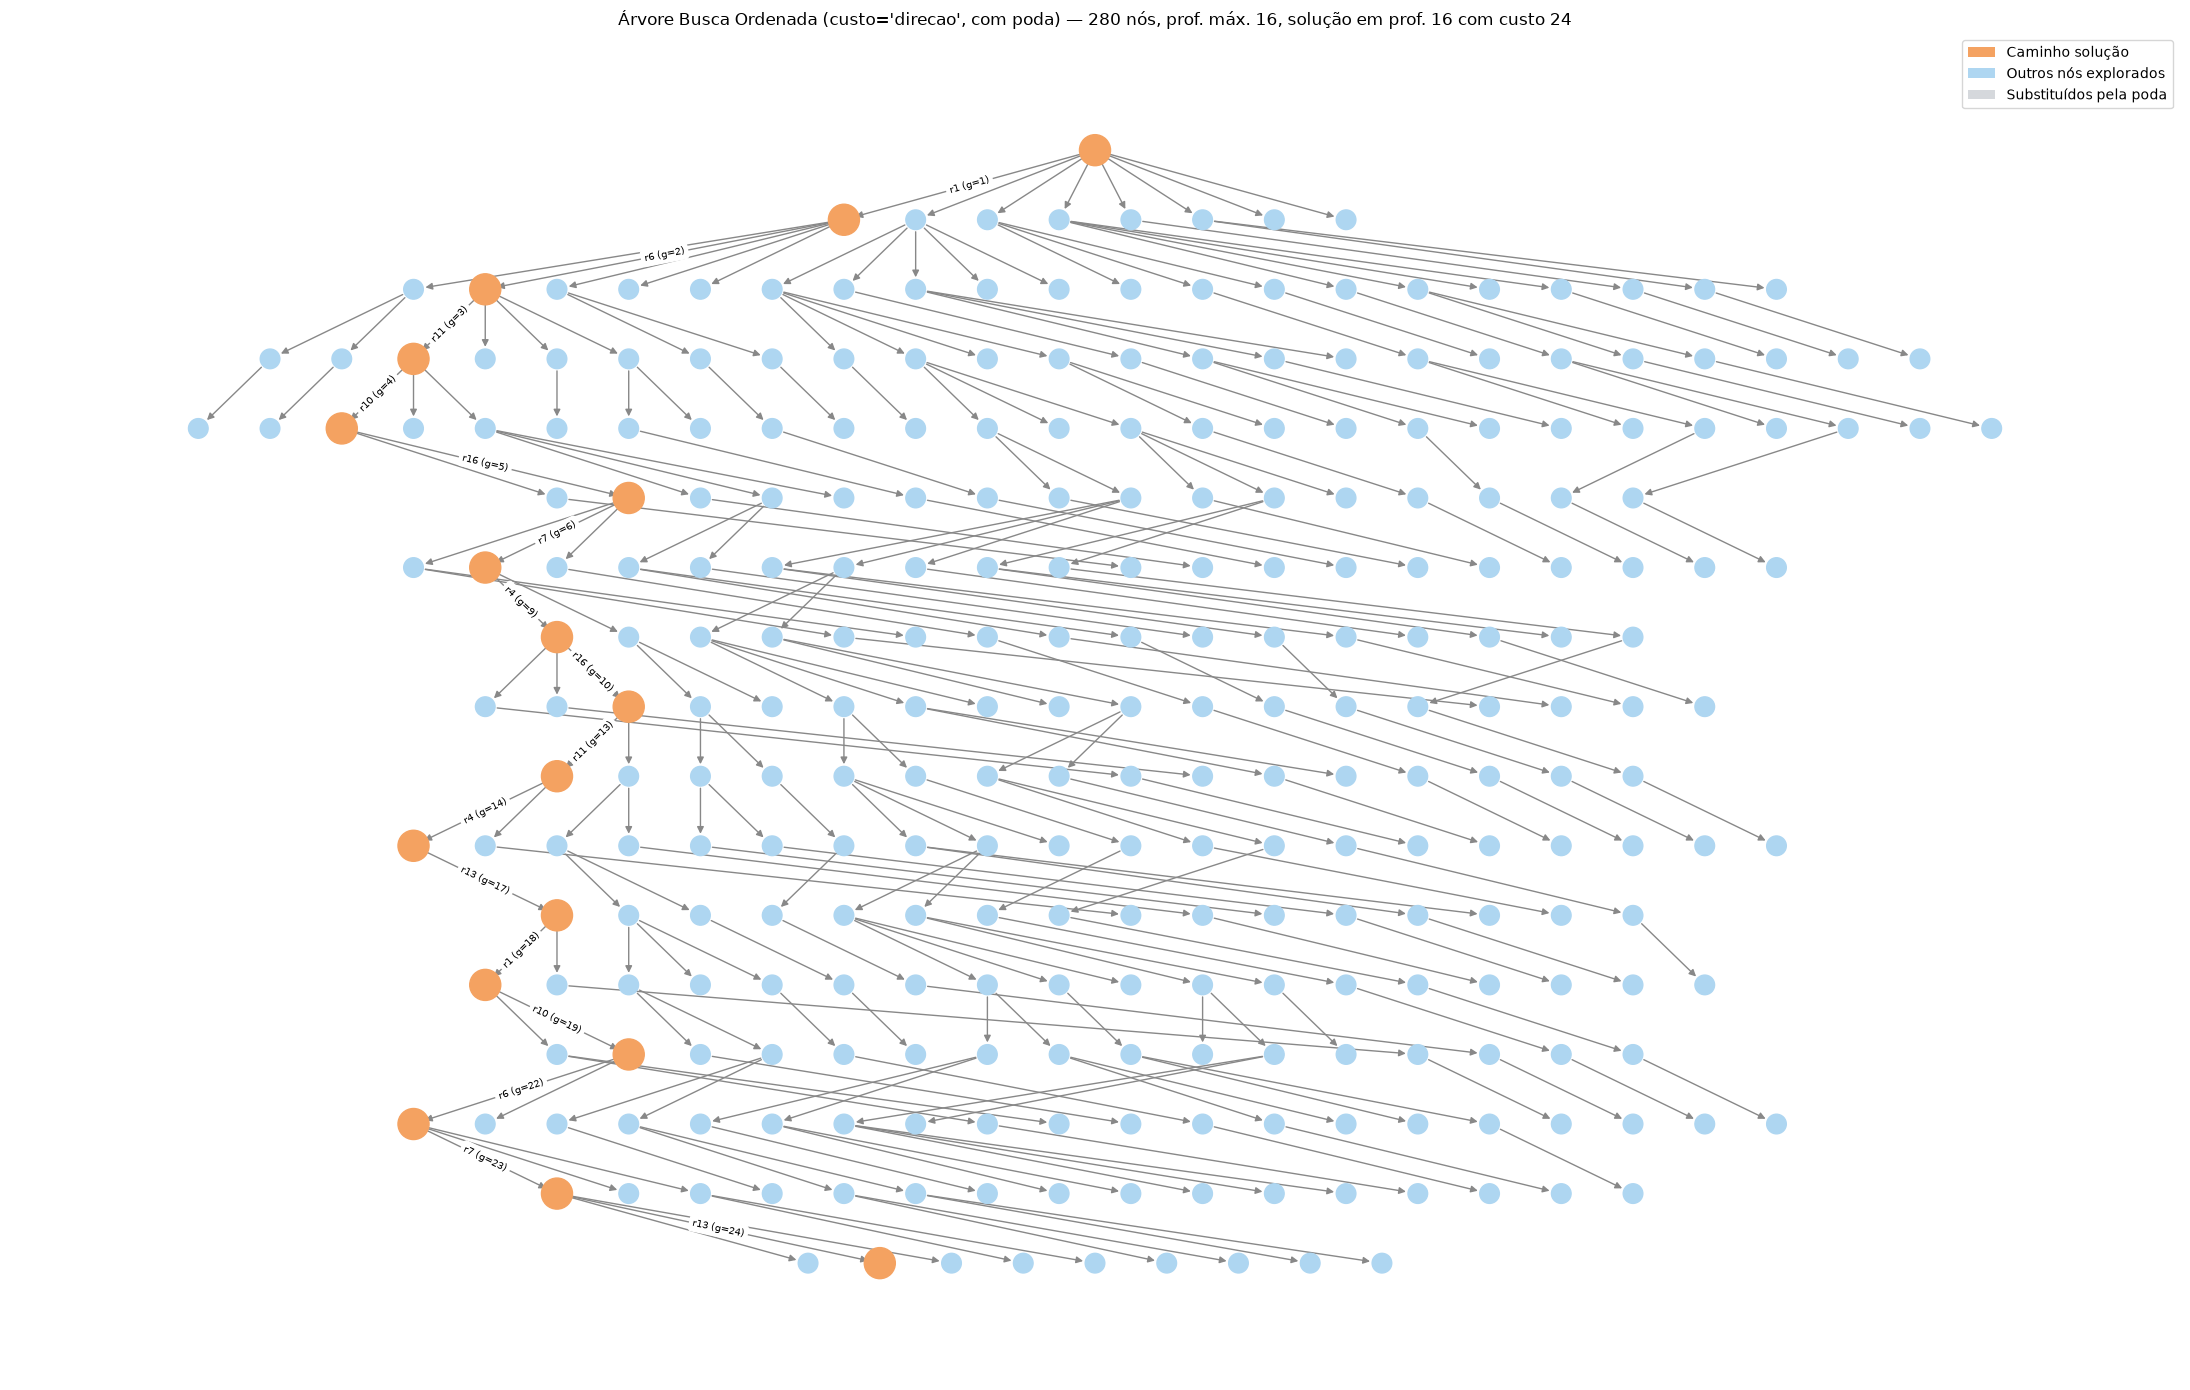

In [4]:
# Visualização da árvore de busca
# Com PRUNING=False + MAX_DEPTH pequeno a árvore é compacta mas mostra estados repetidos
if node_tree is not None:
    ordered.plot_tree(path or [], node_tree, goal_id, cost=COST, pruning=PRUNING)
else:
    print("Sem resultados para visualizar.")


### Comparação entre as duas funções de custo

Roda a Busca Ordenada (com poda) com cada função de custo e mostra, lado a lado, o caminho encontrado e o seu custo sob **ambas** as funções. Assim dá para ver se a solução ótima para uma função também é boa para a outra.


In [5]:
from utils import COST_FUNCTIONS, path_cost

rows = []
for cost_name in COST_FUNCTIONS:
    r = ordered.ordered(INITIAL_STATE, cost=cost_name, order=ORDER, pruning=True)
    _, ap, st, *_ = r
    rows.append({
        "cost": cost_name,
        "moves": len(ap),
        "expanded": st["expanded"],
        "max_open": st["max_open"],
        "applied": ap,
        **{f"custo_{c}": path_cost(ap, INITIAL_STATE, c) for c in COST_FUNCTIONS},
    })

cols   = ["Busca Ordenada com", "Movimentos", "Nós expandidos", "Máx. abertos"] + [f"Custo ({c})" for c in COST_FUNCTIONS]
widths = [20, 12, 16, 14] + [16] * len(COST_FUNCTIONS)

def _hline(l, m, r, f):
    return l + m.join(f * w for w in widths) + r

print(_hline("┌", "┬", "┐", "─"))
print("│" + "│".join(h.center(w) for h, w in zip(cols, widths)) + "│")
print(_hline("├", "┼", "┤", "─"))
for row in rows:
    vals = [row["cost"], row["moves"], row["expanded"], row["max_open"]] + \
           [f"{row[f'custo_{c}']}{' ★' if c == row['cost'] else ''}" for c in COST_FUNCTIONS]
    print("│" + "│".join(str(v).center(w) for v, w in zip(vals, widths)) + "│")
print(_hline("└", "┴", "┘", "─"))
print("★ = custo que a busca estava otimizando\n")

for row in rows:
    print(f"{row['cost']:>8}: {' -> '.join(row['applied'])}")


┌────────────────────┬────────────┬────────────────┬──────────────┬────────────────┬────────────────┐
│ Busca Ordenada com │ Movimentos │ Nós expandidos │ Máx. abertos │Custo (direcao) │Custo (destino) │
├────────────────────┼────────────┼────────────────┼──────────────┼────────────────┼────────────────┤
│      direcao       │     16     │      263       │      34      │      24 ★      │       24       │
│      destino       │     16     │      271       │      40      │       24       │      24 ★      │
└────────────────────┴────────────┴────────────────┴──────────────┴────────────────┴────────────────┘
★ = custo que a busca estava otimizando

 direcao: r1 -> r6 -> r11 -> r10 -> r16 -> r7 -> r4 -> r16 -> r11 -> r4 -> r13 -> r1 -> r10 -> r6 -> r7 -> r13
 destino: r1 -> r6 -> r13 -> r11 -> r10 -> r16 -> r4 -> r7 -> r1 -> r6 -> r13 -> r11 -> r10 -> r16 -> r4 -> r7
